# BÁO CÁO PHÂN TÍCH VÀ TRỰC QUAN HÓA ĐIỂM HỌC TẬP LỚP K58KTP


Dự án này thực hiện:
1. Đọc và làm sạch dữ liệu từ file Excel `DIEM K58KTP.xlsx` (sửa đổi lỗi ngày tháng, giá trị rác, lỗi gõ phím).
2. Tính toán điểm trung bình tích lũy (GPA) của sinh viên và điểm trung bình môn học.
3. Giải đáp 5 câu hỏi phân tích học lực và kết quả học tập.
4. Trực quan hóa dữ liệu bằng 3 biểu đồ chính (phân bố GPA, xếp loại học lực, so sánh môn học).
5. Phân cụm sinh viên bằng thuật toán K-Means kết hợp PCA giảm chiều dữ liệu để tìm ra các nhóm học tập tiêu biểu.
6. Đưa ra kết luận và khuyến nghị sư phạm.

In [1]:
import os # Thư viện hệ thống để xử lý đường dẫn, kiểm tra file tồn tại
import pandas as pd # Thư viện phân tích dữ liệu dạng bảng (DataFrame)
import numpy as np # Thư viện tính toán số học và xử lý ma trận/mảng nhiều chiều
import matplotlib.pyplot as plt # Thư viện vẽ biểu đồ và trực quan hóa dữ liệu
import seaborn as sns # Thư viện vẽ biểu đồ nâng cao dựa trên matplotlib với giao diện đẹp
from sklearn.cluster import KMeans # Thuật toán phân cụm K-Means từ thư viện Scikit-learn
from sklearn.decomposition import PCA # Thuật toán phân tích thành phần chính PCA để giảm chiều dữ liệu
from sklearn.preprocessing import StandardScaler # Hàm chuẩn hóa dữ liệu Z-Score (trung bình = 0, phương sai = 1)

# Thiết lập style nền lưới trắng cho các biểu đồ bằng Seaborn
sns.set_theme(style="whitegrid")
# Cấu hình phông chữ mặc định hiển thị tiếng Việt là Segoe UI (để biểu đồ không bị lỗi phông chữ)
plt.rcParams['font.family'] = 'Segoe UI'
# Đảm bảo các dấu trừ (-) trên trục tọa độ của biểu đồ hiển thị chính xác (không bị lỗi ô vuông)
plt.rcParams['axes.unicode_minus'] = False
# Lệnh cấu hình riêng cho Jupyter Notebook để hiển thị biểu đồ ngay lập tức bên dưới ô code
%matplotlib inline


## 1. Đọc và Làm Sạch Dữ Liệu
Dữ liệu gốc chứa một số lỗi cần làm sạch:
* **Lỗi định dạng ngày tháng (Datetime)**: Excel hiểu nhầm các số thập phân hệ điểm 4 thành ngày tháng (ví dụ: `2026-05-02` thực chất là điểm `2.5`).
* **Lỗi nhập liệu số lớn**: Điểm `3500` môn OOP của sinh viên Nguyễn Văn Hoan thực chất là điểm `3.5`.
* **Lỗi điểm chưa quy đổi**: Điểm `8.5` môn Chủ nghĩa xã hội khoa học của sinh viên Hầu Thị Thanh Huyền thực chất là điểm hệ 10 chưa quy đổi, tương đương điểm `3.5` hệ 4.
* **Loại bỏ chuỗi rác**: Các ký tự `x`, `—`, `-`, `/`, `|`, `Nan` được quy đổi về `NaN` (trống).
* **Loại bỏ sinh viên không có điểm**: 4 sinh viên có toàn bộ điểm trống sẽ bị loại bỏ khỏi danh sách phân tích lớp để tránh làm lệch thống kê.

In [2]:
# Đọc file bảng điểm thô từ Excel, thiết lập header=None để tự xử lý tiêu đề dòng/cột sau đó
df = pd.read_excel('DIEM K58KTP.xlsx', header=None)

# Dòng thứ 2 (chỉ số 1), cột thứ 4 trở đi (chỉ số từ 3 đến hết) chứa Mã số sinh viên (MSSV)
mssvs = df.iloc[1, 3:].values
# Dòng thứ 3 (chỉ số 2), cột thứ 4 trở đi (chỉ số từ 3 đến hết) chứa Họ và Tên sinh viên
names = df.iloc[2, 3:].values
# Cột thứ 2 (chỉ số 1), từ dòng thứ 5 trở đi (chỉ số từ 4 đến hết) chứa Mã môn học
subj_ids = df.iloc[4:, 1].values
# Cột thứ 3 (chỉ số 2), từ dòng thứ 5 trở đi (chỉ số từ 4 đến hết) chứa Tên môn học
subj_names = df.iloc[4:, 2].values
# Ma trận điểm thô nằm từ dòng thứ 5 trở đi và cột thứ 4 trở đi
scores_raw = df.iloc[4:, 3:].values

# Hàm chuẩn hóa và làm sạch giá trị điểm số từ thô sang float hệ 4.0
def clean_score(val):
    # Nếu ô điểm trống (NaN), trả về giá trị NaN của NumPy
    if pd.isna(val):
        return np.nan
    # Nếu điểm số đã là kiểu số (nguyên hoặc thập phân)
    if isinstance(val, (int, float)):
        # Sửa lỗi gõ thừa hai chữ số 0 của sinh viên Nguyễn Văn Hoan môn OOP (3500 điểm thành 3.5)
        if val == 3500:
            return 3.5
        # Quy đổi điểm môn CNXHKH hệ 10 chưa đổi của sinh viên Hầu Thị Thanh Huyền (8.5 thành 3.5 hệ 4)
        if val == 8.5:
            return 3.5
        # Trả về điểm dạng số thập phân float
        return float(val)
    # Nếu Excel hiểu nhầm điểm số thập phân thành kiểu Ngày tháng (Datetime)
    if 'datetime' in str(type(val)) or isinstance(val, pd.Timestamp):
        # Định dạng ngày tháng thành chuỗi YYYY-MM-DD
        dt_str = val.strftime('%Y-%m-%d')
        # Áp dụng các quy luật khôi phục điểm hệ 4 dựa trên dữ liệu lỗi ngày tháng
        if '05-01' in dt_str: return 1.5 # Ngày 1 tháng 5 tương đương điểm 1.5
        if '05-02' in dt_str: return 2.5 # Ngày 2 tháng 5 tương đương điểm 2.5
        if '05-03' in dt_str: return 3.5 # Ngày 3 tháng 5 tương đương điểm 3.5
        if '07-03' in dt_str: return 3.7 # Ngày 3 tháng 7 tương đương điểm 3.7
        if '03-02' in dt_str: return 2.3 # Ngày 2 tháng 3 tương đương điểm 2.3
        return np.nan # Trả về trống đối với định dạng ngày khác không khớp
    # Chuyển đổi sang dạng chuỗi văn bản và loại bỏ khoảng trắng hai đầu để làm sạch ký tự rác
    val_str = str(val).strip()
    val_lower = val_str.lower()
    # Các ký hiệu thể hiện việc bỏ thi, hoãn thi, trống điểm được quy đổi thống nhất về NaN
    if val_lower in ['nan', 'nann', '—', '-', '/', '|', 'x']:
        return np.nan
    # Thử chuyển chuỗi sang số float, nếu có lỗi phát sinh thì trả về NaN
    try:
        return float(val_str)
    except ValueError:
        return np.nan

# Áp dụng hàm làm sạch clean_score lên toàn bộ ma trận điểm số thô bằng np.vectorize
cleaned_scores = np.vectorize(clean_score, otypes=[float])(scores_raw)
# In kích thước ma trận điểm sau khi đã chuẩn hóa và làm sạch thành công
print(f"Kích thước ma trận điểm đã làm sạch: {cleaned_scores.shape[0]} môn học, {cleaned_scores.shape[1]} sinh viên")


Kích thước ma trận điểm đã làm sạch: 52 môn học, 71 sinh viên


## 2. Tính Toán Điểm Trung Bình
Chúng ta tính toán điểm trung bình tích lũy (GPA) cho mỗi sinh viên và điểm trung bình cho mỗi môn học (bỏ qua các giá trị khuyết thiếu `NaN`).

In [3]:
# Tính điểm trung bình tích lũy (GPA) cho mỗi sinh viên (trung bình theo cột, bỏ qua NaN)
student_gpas = np.nanmean(cleaned_scores, axis=0)

# Tạo mặt nạ boolean để lọc sinh viên có điểm hợp lệ (không bị NaN toàn bộ)
valid_mask = ~np.isnan(student_gpas)
# In ra số lượng sinh viên không có bất kỳ điểm môn học nào được đăng ký
print(f"Loại bỏ {np.sum(~valid_mask)} sinh viên không đăng ký điểm:")
for i, is_valid in enumerate(valid_mask):
    if not is_valid:
         # In ra chi tiết MSSV và họ tên các sinh viên bị loại bỏ khỏi thống kê
         print(f" - MSSV: {mssvs[i]}, Tên: {names[i]}")

# Tạo DataFrame lưu trữ thông tin của các sinh viên hợp lệ gồm MSSV, Họ tên và GPA tích lũy
df_students = pd.DataFrame({
    'MSSV': mssvs[valid_mask],
    'HoTen': names[valid_mask],
    'GPA': student_gpas[valid_mask]
})

# Tính điểm trung bình môn học của từng môn (trung bình theo hàng, bỏ qua các giá trị NaN)
subject_gpas = np.nanmean(cleaned_scores, axis=1)
# Tạo DataFrame lưu trữ thông tin môn học gồm Mã môn, Tên môn và Điểm trung bình môn học
df_subjects = pd.DataFrame({
    'MaMon': subj_ids,
    'TenMon': subj_names,
    'AvgScore': subject_gpas
})

# Tạo bảng dữ liệu điểm chi tiết đã làm sạch với chỉ mục là tên môn học và cột là tên + MSSV sinh viên
df_cleaned_export = pd.DataFrame(cleaned_scores, index=subj_names, columns=[f"{n} ({m})" for n, m in zip(names, mssvs)])
# Lưu bảng dữ liệu điểm đã làm sạch ra một file Excel riêng để phục vụ lưu trữ, tra cứu
df_cleaned_export.to_excel("DIEM_K58KTP_DA_LAM_SACH.xlsx")
# Thông báo xuất file thành công
print("\n-> Đã xuất dữ liệu làm sạch ra file DIEM_K58KTP_DA_LAM_SACH.xlsx")


Loại bỏ 4 sinh viên không đăng ký điểm:
 - MSSV: K225480106018, Tên: Trần Quang Hiệp
 - MSSV: K225480106089, Tên: Ma Quốc Hiếu
 - MSSV: K225480106094, Tên: Nông Hồ Nhật
 - MSSV: K225480106069, Tên: Lê Ngọc Tú

-> Đã xuất dữ liệu làm sạch ra file DIEM_K58KTP_DA_LAM_SACH.xlsx


C:\Users\Admin\AppData\Local\Temp\ipykernel_2308\2613071959.py:2: RuntimeWarning: Mean of empty slice
  student_gpas = np.nanmean(cleaned_scores, axis=0)


## 3. Giải Đáp 5 Câu Hỏi Phân Tích
Chúng ta thực hiện trả lời lần lượt các câu hỏi phân tích bằng cách truy vấn trên dữ liệu đã tính toán.

1. Điểm trung bình của lớp K58KTP là: 2.6923 (Thang điểm 4.0)


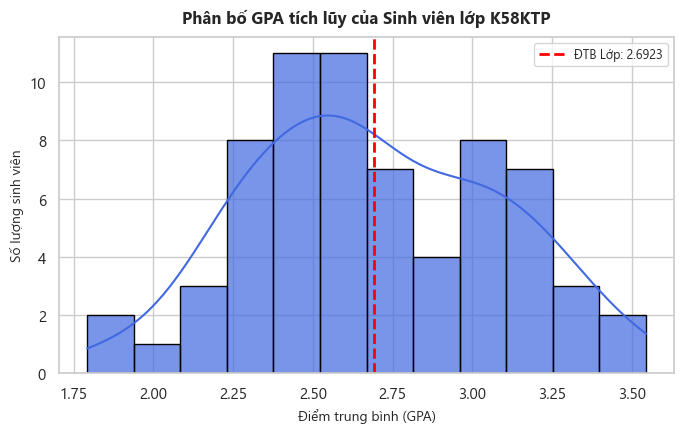

In [4]:
# Câu 1: Tính điểm trung bình GPA tích lũy của cả lớp K58KTP bằng cách lấy trung bình cột GPA
class_avg_gpa = df_students['GPA'].mean()
# In kết quả điểm trung bình GPA tích lũy của lớp làm tròn tới 4 chữ số thập phân
print(f"1. Điểm trung bình của lớp K58KTP là: {class_avg_gpa:.4f} (Thang điểm 4.0)")

# Tạo một cửa sổ biểu đồ mới có kích thước rộng 7 inches, cao 4.5 inches
plt.figure(figsize=(7, 4.5))
# Vẽ biểu đồ phân bố tần suất (Histogram) kết hợp đường cong mật độ (KDE) màu xanh royalblue
sns.histplot(df_students['GPA'], bins=12, kde=True, color='royalblue', edgecolor='black', alpha=0.7)
# Vẽ đường thẳng gióng dọc màu đỏ dạng đứt nét thể hiện giá trị điểm trung bình lớp
plt.axvline(class_avg_gpa, color='red', linestyle='--', linewidth=2, label=f'ĐTB Lớp: {class_avg_gpa:.4f}')
# Thiết lập tiêu đề biểu đồ cỡ chữ 12, in đậm và khoảng cách đệm pad=10
plt.title('Phân bố GPA tích lũy của Sinh viên lớp K58KTP', fontsize=12, fontweight='bold', pad=10)
# Đặt tên nhãn trục hoành (trục ngang) là điểm trung bình GPA
plt.xlabel('Điểm trung bình (GPA)', fontsize=10)
# Đặt tên nhãn trục tung (trục dọc) là số lượng sinh viên
plt.ylabel('Số lượng sinh viên', fontsize=10)
# Hiển thị chú thích (legend) cỡ chữ 9 ở góc tối ưu
plt.legend(fontsize=9)
# Tự động căn chỉnh các lề và khoảng cách biểu đồ để không bị tràn chữ
plt.tight_layout()
# Hiển thị biểu đồ ra màn hình
plt.show()


2. Môn học có điểm trung bình cao nhất là: Lập trình Python (TEE0479) với 3.6242


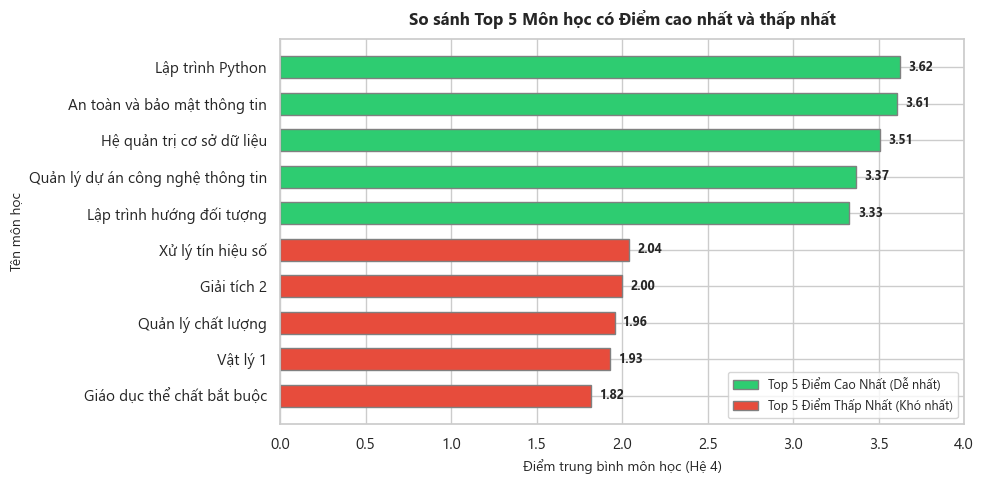

In [5]:
# Câu 2: Tìm hàng chứa môn học có điểm trung bình cao nhất bằng phương pháp lấy chỉ số lớn nhất idxmax()
highest_subj = df_subjects.loc[df_subjects['AvgScore'].idxmax()]
# In ra tên môn học, mã môn học và điểm trung bình tương ứng của môn dễ nhất lớp
print(f"2. Môn học có điểm trung bình cao nhất là: {highest_subj['TenMon']} ({highest_subj['MaMon']}) với {highest_subj['AvgScore']:.4f}")

# Sắp xếp danh sách môn học giảm dần theo điểm trung bình để phục vụ vẽ biểu đồ so sánh
df_sorted_subjs = df_subjects.sort_values(by='AvgScore', ascending=False)
# Trích xuất 5 môn học có điểm trung bình cao nhất (Top 5 dễ nhất)
top_5 = df_sorted_subjs.head(5)
# Trích xuất 5 môn học có điểm trung bình thấp nhất (Top 5 khó nhất)
bottom_5 = df_sorted_subjs.tail(5)
# Nối hai tập dữ liệu Top 5 cao nhất và Top 5 thấp nhất thành một DataFrame chung
compare_df = pd.concat([top_5, bottom_5])
# Gán nhãn nhóm tương ứng cho các môn học để phân biệt màu sắc
compare_df['Group'] = ['Top 5 Cao Nhất']*5 + ['Top 5 Thấp Nhất']*5
# Khởi tạo kích thước cửa sổ biểu đồ rộng 10 inches, cao 5 inches
plt.figure(figsize=(10, 5))
# Đảo ngược thứ tự các môn trong bảng vẽ để các môn điểm cao được xếp lên trên cùng của biểu đồ ngang
compare_df_plot = compare_df.iloc[::-1]
# Thiết lập từ điển màu sắc: xanh lá cây cho môn học dễ, đỏ cho môn học khó
colors_dict = {'Top 5 Cao Nhất': '#2ecc71', 'Top 5 Thấp Nhất': '#e74c3c'}
# Ánh xạ nhãn nhóm sang danh sách màu sắc tương ứng để gán cho từng cột biểu đồ
bar_colors = [colors_dict[g] for g in compare_df_plot['Group']]
# Vẽ biểu đồ cột ngang (Horizontal Bar Chart)
bars = plt.barh(compare_df_plot['TenMon'], compare_df_plot['AvgScore'], color=bar_colors, edgecolor='grey', height=0.6)
# Thiết lập tiêu đề cho biểu đồ
plt.title('So sánh Top 5 Môn học có Điểm cao nhất và thấp nhất', fontsize=12, fontweight='bold', pad=10)
# Đặt tên nhãn cho trục hoành (trục ngang là điểm trung bình môn)
plt.xlabel('Điểm trung bình môn học (Hệ 4)', fontsize=10)
# Đặt tên nhãn cho trục tung (trục dọc là tên các môn học)
plt.ylabel('Tên môn học', fontsize=10)
# Giới hạn trục hoành chạy từ 0 đến tối đa 4.0 điểm hệ 4
plt.xlim(0, 4.0)
# Duyệt qua từng cột trong biểu đồ để điền số điểm cụ thể lên đầu cột
for bar in bars:
    xval = bar.get_width() # Lấy chiều dài của cột (tương ứng với giá trị điểm số)
    # Ghi nhãn điểm số làm tròn 2 chữ số thập phân tại vị trí đầu cột
    plt.text(xval + 0.05, bar.get_y() + bar.get_height()/2, f"{xval:.2f}", ha='left', va='center', fontsize=9, fontweight='bold')
# Nạp thư viện tạo mảng màu chú thích tùy chỉnh
from matplotlib.patches import Patch
# Tạo nhãn chú thích tùy chỉnh để người xem dễ phân biệt vùng màu xanh lá và màu đỏ
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='grey', label='Top 5 Điểm Cao Nhất (Dễ nhất)'),
                   Patch(facecolor='#e74c3c', edgecolor='grey', label='Top 5 Điểm Thấp Nhất (Khó nhất)')]
# Hiển thị bảng chú thích ở góc dưới bên phải biểu đồ
plt.legend(handles=legend_elements, loc='lower right', fontsize=9)
# Căn chỉnh bố cục lề tối ưu
plt.tight_layout()
# Hiển thị biểu đồ
plt.show()


3. Môn học có điểm trung bình thấp nhất là: Giáo dục thể chất bắt buộc (BAS0109) với 1.8185


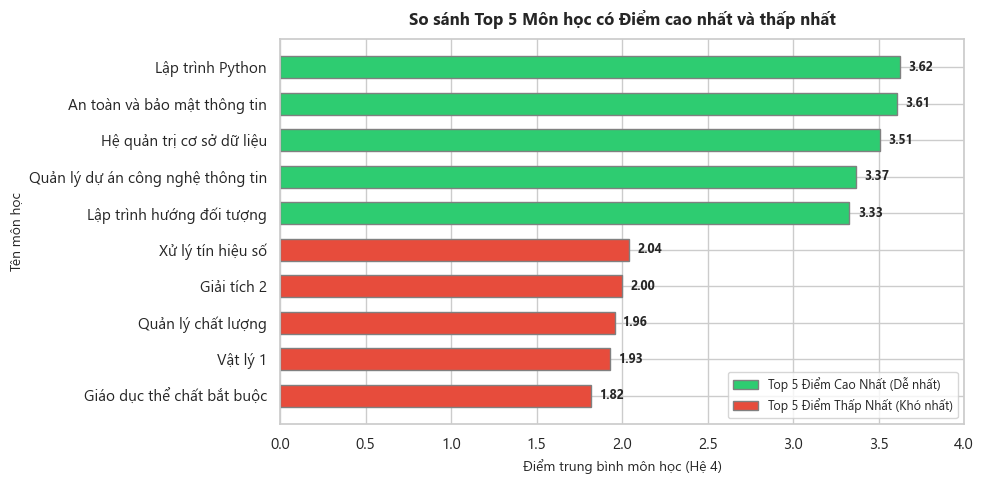

In [6]:
# Câu 3: Tìm hàng chứa môn học có điểm trung bình thấp nhất bằng phương pháp lấy chỉ số nhỏ nhất idxmin()
lowest_subj = df_subjects.loc[df_subjects['AvgScore'].idxmin()]
# In ra tên môn học, mã môn học và điểm trung bình môn học tương ứng của môn khó nhất lớp K58KTP
print(f"3. Môn học có điểm trung bình thấp nhất là: {lowest_subj['TenMon']} ({lowest_subj['MaMon']}) với {lowest_subj['AvgScore']:.4f}")

# Sắp xếp danh sách môn học giảm dần theo điểm trung bình để phục vụ vẽ biểu đồ so sánh
df_sorted_subjs = df_subjects.sort_values(by='AvgScore', ascending=False)
# Trích xuất 5 môn học có điểm trung bình cao nhất (Top 5 dễ nhất)
top_5 = df_sorted_subjs.head(5)
# Trích xuất 5 môn học có điểm trung bình thấp nhất (Top 5 khó nhất)
bottom_5 = df_sorted_subjs.tail(5)
# Nối hai tập dữ liệu Top 5 cao nhất và Top 5 thấp nhất thành một DataFrame chung
compare_df = pd.concat([top_5, bottom_5])
# Gán nhãn nhóm tương ứng cho các môn học để phân biệt màu sắc
compare_df['Group'] = ['Top 5 Cao Nhất']*5 + ['Top 5 Thấp Nhất']*5
# Khởi tạo kích thước cửa sổ biểu đồ rộng 10 inches, cao 5 inches
plt.figure(figsize=(10, 5))
# Đảo ngược thứ tự các môn trong bảng vẽ để các môn điểm cao được xếp lên trên cùng của biểu đồ ngang
compare_df_plot = compare_df.iloc[::-1]
# Thiết lập từ điển màu sắc: xanh lá cây cho môn học dễ, đỏ cho môn học khó
colors_dict = {'Top 5 Cao Nhất': '#2ecc71', 'Top 5 Thấp Nhất': '#e74c3c'}
# Ánh xạ nhãn nhóm sang danh sách màu sắc tương ứng để gán cho từng cột biểu đồ
bar_colors = [colors_dict[g] for g in compare_df_plot['Group']]
# Vẽ biểu đồ cột ngang (Horizontal Bar Chart)
bars = plt.barh(compare_df_plot['TenMon'], compare_df_plot['AvgScore'], color=bar_colors, edgecolor='grey', height=0.6)
# Thiết lập tiêu đề cho biểu đồ
plt.title('So sánh Top 5 Môn học có Điểm cao nhất và thấp nhất', fontsize=12, fontweight='bold', pad=10)
# Đặt tên nhãn cho trục hoành (trục ngang là điểm trung bình môn)
plt.xlabel('Điểm trung bình môn học (Hệ 4)', fontsize=10)
# Đặt tên nhãn cho trục tung (trục dọc là tên các môn học)
plt.ylabel('Tên môn học', fontsize=10)
# Giới hạn trục hoành chạy từ 0 đến tối đa 4.0 điểm hệ 4
plt.xlim(0, 4.0)
# Duyệt qua từng cột trong biểu đồ để điền số điểm cụ thể lên đầu cột
for bar in bars:
    xval = bar.get_width() # Lấy chiều dài của cột (tương ứng với giá trị điểm số)
    # Ghi nhãn điểm số làm tròn 2 chữ số thập phân tại vị trí đầu cột
    plt.text(xval + 0.05, bar.get_y() + bar.get_height()/2, f"{xval:.2f}", ha='left', va='center', fontsize=9, fontweight='bold')
# Nạp thư viện tạo mảng màu chú thích tùy chỉnh
from matplotlib.patches import Patch
# Tạo nhãn chú thích tùy chỉnh để người xem dễ phân biệt vùng màu xanh lá và màu đỏ
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='grey', label='Top 5 Điểm Cao Nhất (Dễ nhất)'),
                   Patch(facecolor='#e74c3c', edgecolor='grey', label='Top 5 Điểm Thấp Nhất (Khó nhất)')]
# Hiển thị bảng chú thích ở góc dưới bên phải biểu đồ
plt.legend(handles=legend_elements, loc='lower right', fontsize=9)
# Căn chỉnh bố cục lề tối ưu
plt.tight_layout()
# Hiển thị biểu đồ
plt.show()


4. Số lượng sinh viên theo từng phân loại học lực:
   - Loại Giỏi      :  8 sinh viên (11.94%)
   - Loại Khá       : 37 sinh viên (55.22%)
   - Loại Trung bình: 20 sinh viên (29.85%)
   - Loại Yếu       :  2 sinh viên (2.99%)


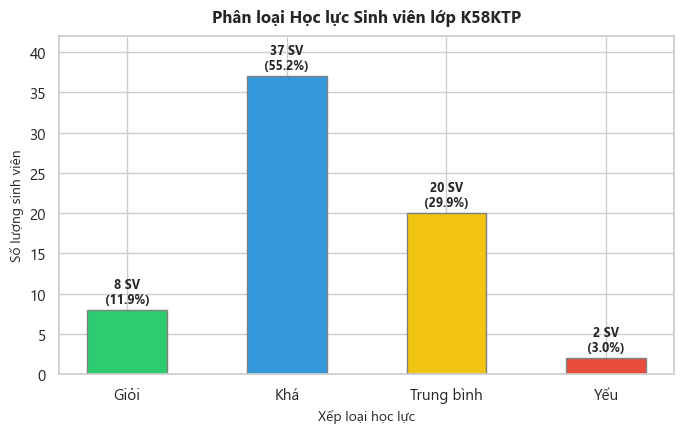

In [7]:
# Câu 4: Định nghĩa hàm phân loại học lực sinh viên dựa trên GPA tích lũy hệ 4.0
def classify_student(gpa):
    if gpa >= 3.2: return 'Giỏi' # GPA từ 3.2 trở lên đạt học lực Giỏi
    elif gpa >= 2.5: return 'Khá' # GPA từ 2.5 đến dưới 3.2 đạt học lực Khá
    elif gpa >= 2.0: return 'Trung bình' # GPA từ 2.0 đến dưới 2.5 đạt học lực Trung bình
    else: return 'Yếu' # GPA dưới 2.0 xếp loại học lực Yếu

# Áp dụng hàm phân loại lên cột GPA của từng sinh viên để tạo cột xếp loại học lực 'XepLoai'
df_students['XepLoai'] = df_students['GPA'].apply(classify_student)
# Đếm số lượng sinh viên tương ứng với mỗi loại học lực và sắp xếp theo thứ tự Giỏi -> Khá -> Trung bình -> Yếu
xep_loai_counts = df_students['XepLoai'].value_counts().reindex(['Giỏi', 'Khá', 'Trung bình', 'Yếu'], fill_value=0)

# In kết quả số lượng sinh viên và phần trăm tỉ lệ tương ứng của từng xếp loại học lực ra console
print("4. Số lượng sinh viên theo từng phân loại học lực:")
for k, v in xep_loai_counts.items():
    percentage = (v / len(df_students)) * 100 # Tính tỷ lệ phần trăm của phân loại này trong lớp
    print(f"   - Loại {k:10}: {v:2d} sinh viên ({percentage:.2f}%)")

# Khởi tạo cửa sổ vẽ biểu đồ xếp loại rộng 7 inches, cao 4.5 inches
plt.figure(figsize=(7, 4.5))
# Thiết lập các màu sắc đặc trưng: xanh lá (Giỏi), xanh lam (Khá), vàng (Trung bình), đỏ (Yếu)
colors = ['#2ecc71', '#3498db', '#f1c40f', '#e74c3c']
# Vẽ biểu đồ cột thẳng đứng (Vertical Bar Chart) thể hiện phân loại học lực lớp
bars = plt.bar(xep_loai_counts.index, xep_loai_counts.values, color=colors, edgecolor='grey', width=0.5)
# Ghi tiêu đề chính thức cho biểu đồ
plt.title('Phân loại Học lực Sinh viên lớp K58KTP', fontsize=12, fontweight='bold', pad=10)
# Đặt tên nhãn cho trục hoành (trục ngang là xếp loại học lực)
plt.xlabel('Xếp loại học lực', fontsize=10)
# Đặt tên nhãn cho trục tung (trục dọc là số lượng sinh viên)
plt.ylabel('Số lượng sinh viên', fontsize=10)
# Thiết lập giới hạn trục tung cao hơn giá trị cột cao nhất để tránh nhãn text bị đè
plt.ylim(0, max(xep_loai_counts.values) + 5)
# Duyệt qua từng cột biểu đồ để hiển thị số lượng và tỉ lệ phần trăm trực quan trên đầu cột
for bar in bars:
    yval = bar.get_height() # Lấy chiều cao của cột (số sinh viên thuộc xếp loại này)
    # Hiển thị số lượng sinh viên và phần trăm tương ứng trực quan ở đầu mỗi cột
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval} SV\n({yval/len(df_students)*100:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')
# Căn chỉnh lề tự động
plt.tight_layout()
# Hiển thị biểu đồ
plt.show()


5. Sinh viên có điểm trung bình cao nhất là: Trần Thị Thu Hà (MSSV: K225480106009) với GPA: 3.5451


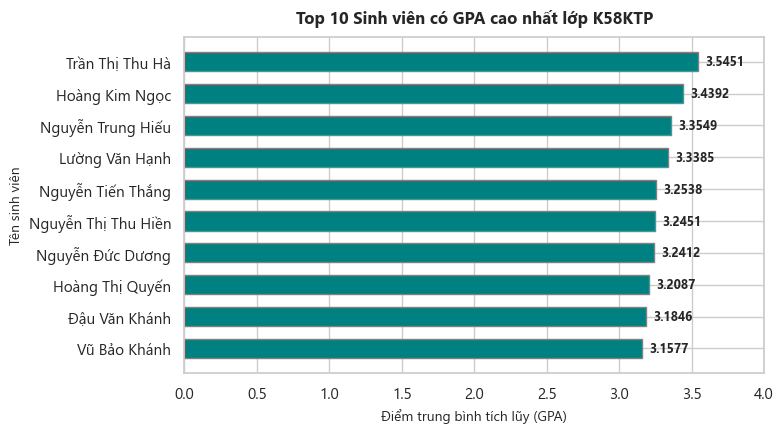

In [8]:
# Câu 5: Tìm sinh viên có điểm trung bình tích lũy GPA cao nhất lớp (Thủ khoa) bằng idxmax() trên cột GPA
best_student = df_students.loc[df_students['GPA'].idxmax()]
# In thông tin thủ khoa gồm họ tên, mã số sinh viên (MSSV) và GPA đạt được ra màn hình
print(f"5. Sinh viên có điểm trung bình cao nhất là: {best_student['HoTen']} (MSSV: {best_student['MSSV']}) với GPA: {best_student['GPA']:.4f}")

# Khởi tạo cửa sổ vẽ biểu đồ kích thước rộng 8 inches, cao 4.5 inches
plt.figure(figsize=(8, 4.5))
# Sắp xếp danh sách sinh viên theo GPA giảm dần và lấy ra 10 sinh viên đứng đầu lớp (Top 10)
df_top_students = df_students.sort_values(by='GPA', ascending=False).head(10)
# Đảo ngược danh sách top 10 để vẽ sinh viên có điểm cao nhất ở vị trí trên cùng của biểu đồ ngang
df_top_students_plot = df_top_students.iloc[::-1]
# Vẽ biểu đồ cột ngang (Horizontal Bar Chart) biểu diễn top 10 sinh viên có GPA cao nhất với tông màu xanh cổ vịt (teal)
bars_top = plt.barh(df_top_students_plot['HoTen'], df_top_students_plot['GPA'], color='teal', edgecolor='grey', height=0.6)
# Thiết lập tiêu đề biểu đồ
plt.title('Top 10 Sinh viên có GPA cao nhất lớp K58KTP', fontsize=12, fontweight='bold', pad=10)
# Đặt tên nhãn trục hoành (trục ngang là điểm GPA tích lũy)
plt.xlabel('Điểm trung bình tích lũy (GPA)', fontsize=10)
# Đặt tên nhãn trục tung (trục dọc là tên sinh viên)
plt.ylabel('Tên sinh viên', fontsize=10)
# Giới hạn thang trục hoành từ 0 đến 4.0 điểm hệ 4.0
plt.xlim(0, 4.0)
# Duyệt qua từng cột sinh viên để ghi giá trị GPA cụ thể lên đầu cột biểu đồ
for bar in bars_top:
    xval = bar.get_width() # Lấy giá trị GPA tương ứng với độ dài cột ngang
    # Hiển thị điểm số làm tròn tới 4 chữ số thập phân sát cạnh đầu cột
    plt.text(xval + 0.05, bar.get_y() + bar.get_height()/2, f"{xval:.4f}", ha='left', va='center', fontsize=9, fontweight='bold')
# Căn chỉnh lề biểu đồ tự động
plt.tight_layout()
# Hiển thị biểu đồ
plt.show()


## 4. Vẽ 3 Biểu Đồ Trực Quan Hóa
Chúng ta hiển thị trực quan các kết quả bằng biểu đồ.

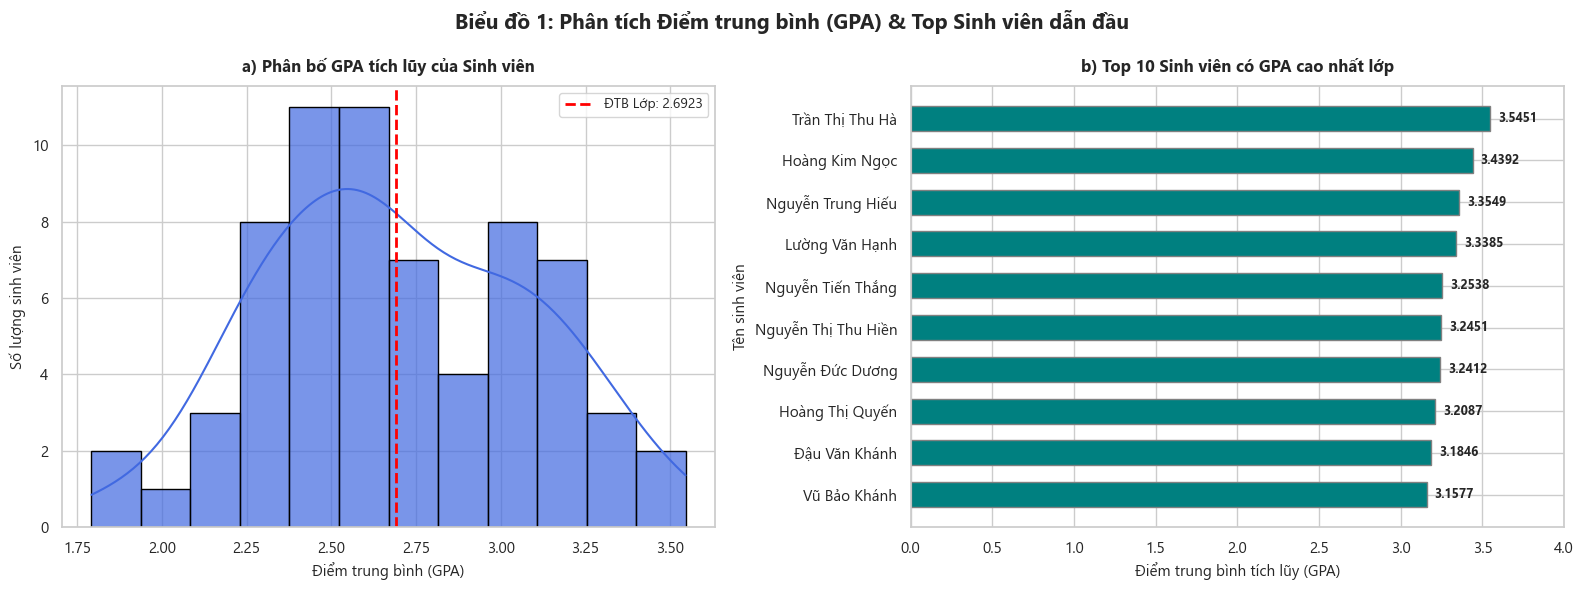

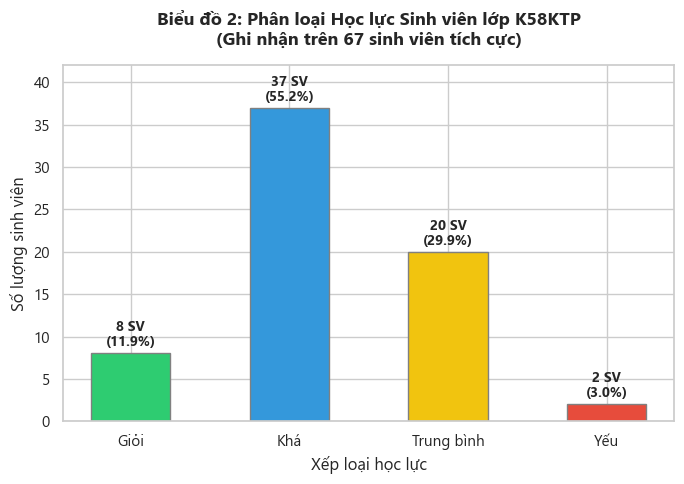

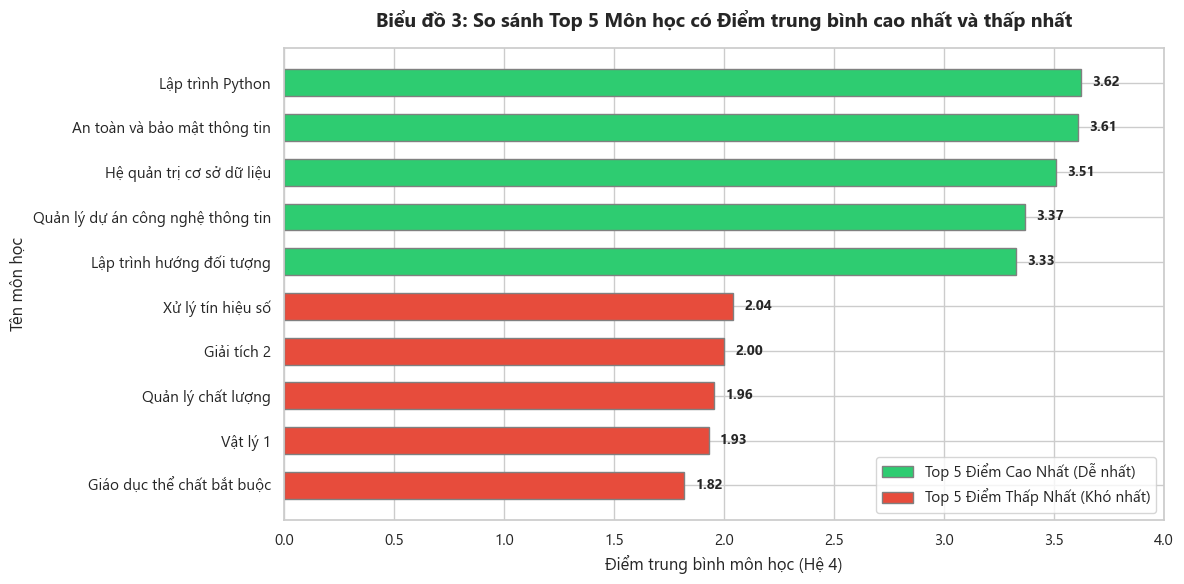

In [9]:
# Biểu đồ tổng kết: Vẽ hình ghép gồm nhiều ô (subplot) thể hiện phân bố GPA và Top 10 sinh viên dẫn đầu
# Khởi tạo lưới đồ họa gồm 1 dòng, 2 cột với kích thước tổng thể là rộng 16 inches, cao 6 inches
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot thứ nhất (ô bên trái): Vẽ biểu đồ phân bố điểm trung bình GPA của toàn bộ sinh viên
sns.histplot(df_students['GPA'], bins=12, kde=True, color='royalblue', edgecolor='black', alpha=0.7, ax=axes[0])
# Vẽ đường gióng dọc đứt nét màu đỏ thể hiện mức điểm trung bình lớp GPA trên biểu đồ phân bố
axes[0].axvline(class_avg_gpa, color='red', linestyle='--', linewidth=2, label=f'ĐTB Lớp: {class_avg_gpa:.4f}')
# Đặt tiêu đề cho biểu đồ phân bố GPA con bên trái
axes[0].set_title('a) Phân bố GPA tích lũy của Sinh viên', fontsize=12, fontweight='bold', pad=10)
# Đặt tên nhãn trục hoành
axes[0].set_xlabel('Điểm trung bình (GPA)', fontsize=11)
# Đặt tên nhãn trục tung
axes[0].set_ylabel('Số lượng sinh viên', fontsize=11)
# Hiển thị bảng chú thích cho biểu đồ con bên trái
axes[0].legend(fontsize=10)

# Subplot thứ hai (ô bên phải): Vẽ biểu đồ Top 10 sinh viên có GPA cao nhất
# Sắp xếp sinh viên theo GPA giảm dần và lấy ra 10 sinh viên đứng đầu lớp
df_top_students = df_students.sort_values(by='GPA', ascending=False).head(10)
# Đảo ngược danh sách top 10 để hiển thị thủ khoa trên cùng của biểu đồ con cột ngang
df_top_students_plot = df_top_students.iloc[::-1]
# Vẽ biểu đồ cột ngang top 10 sinh viên màu xanh cổ vịt (teal) trên phân hệ ô thứ 2 (axes[1])
bars_top = axes[1].barh(df_top_students_plot['HoTen'], df_top_students_plot['GPA'], color='teal', edgecolor='grey', height=0.6)
# Đặt tiêu đề cho biểu đồ con bên phải
axes[1].set_title('b) Top 10 Sinh viên có GPA cao nhất lớp', fontsize=12, fontweight='bold', pad=10)
# Đặt tên nhãn trục ngang
axes[1].set_xlabel('Điểm trung bình tích lũy (GPA)', fontsize=11)
# Đặt tên nhãn trục dọc
axes[1].set_ylabel('Tên sinh viên', fontsize=11)
# Giới hạn trục ngang là 4.0 điểm hệ 4
axes[1].set_xlim(0, 4.0)

# Duyệt qua từng cột trong biểu đồ cột ngang top 10 để điền điểm số cụ thể lên đầu cột
for bar in bars_top:
    xval = bar.get_width() # Chiều rộng cột là điểm GPA tương ứng
    # Hiển thị điểm số với định dạng 4 chữ số thập phân tại vị trí đầu cột tương ứng
    axes[1].text(xval + 0.05, bar.get_y() + bar.get_height()/2, f"{xval:.4f}", 
                 ha='left', va='center', fontsize=9, fontweight='bold')

# Thiết lập tiêu đề tổng quát cho cả biểu đồ ghép, in đậm cỡ chữ 15, căn ở vị trí phía trên
plt.suptitle('Biểu đồ 1: Phân tích Điểm trung bình (GPA) & Top Sinh viên dẫn đầu', fontsize=15, fontweight='bold', y=0.98)
# Căn chỉnh bố cục lề để các biểu đồ con không bị chồng chéo
plt.tight_layout()
# Hiển thị ảnh biểu đồ ghép
plt.show()

# Biểu đồ 2: Vẽ biểu đồ phân loại học lực sinh viên của lớp K58KTP
# Khởi tạo cửa sổ vẽ rộng 7 inches, cao 5 inches
plt.figure(figsize=(7, 5))
# Định nghĩa danh sách các tông màu biểu đồ: xanh lá (Giỏi), xanh lam (Khá), vàng (Trung bình), đỏ (Yếu)
colors = ['#2ecc71', '#3498db', '#f1c40f', '#e74c3c']
# Vẽ biểu đồ cột thẳng đứng thể hiện tần suất phân loại học lực của lớp
bars = plt.bar(xep_loai_counts.index, xep_loai_counts.values, color=colors, edgecolor='grey', width=0.5)
# Ghi tiêu đề chính thức cho biểu đồ xếp loại học lực
plt.title('Biểu đồ 2: Phân loại Học lực Sinh viên lớp K58KTP\n(Ghi nhận trên 67 sinh viên tích cực)', fontsize=13, fontweight='bold', pad=15)
# Đặt tên nhãn trục hoành
plt.xlabel('Xếp loại học lực', fontsize=12)
# Đặt tên nhãn trục tung
plt.ylabel('Số lượng sinh viên', fontsize=12)
# Thiết lập giới hạn trục tung cao hơn giá trị cao nhất 5 đơn vị để biểu đồ thoáng đãng
plt.ylim(0, max(xep_loai_counts.values) + 5)

# Duyệt qua từng cột để hiển thị thông tin số lượng sinh viên và tỷ lệ phần trăm tương ứng lên đỉnh cột
for bar in bars:
    yval = bar.get_height() # Lấy chiều cao cột (số sinh viên)
    # Hiển thị chuỗi văn bản gồm số lượng SV và tỷ lệ % làm tròn 1 chữ số thập phân
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval} SV\n({yval/len(df_students)*100:.1f}%)", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
# Căn chỉnh lề biểu đồ
plt.tight_layout()
# Hiển thị biểu đồ
plt.show()

# Biểu đồ 3: Vẽ biểu đồ so sánh Top 5 môn học dễ nhất (điểm cao nhất) và Top 5 môn khó nhất (điểm thấp nhất)
# Sắp xếp danh sách môn học giảm dần theo điểm trung bình
df_sorted_subjs = df_subjects.sort_values(by='AvgScore', ascending=False)
# Trích xuất 5 môn học đứng đầu (Top 5 điểm cao nhất)
top_5 = df_sorted_subjs.head(5)
# Trích xuất 5 môn học đứng cuối (Top 5 điểm thấp nhất)
bottom_5 = df_sorted_subjs.tail(5)
# Ghép nối dữ liệu của hai nhóm môn học thành một bảng so sánh chung
compare_df = pd.concat([top_5, bottom_5])
# Gán nhãn nhóm phân biệt màu sắc cho từng phần tử môn học
compare_df['Group'] = ['Top 5 Cao Nhất']*5 + ['Top 5 Thấp Nhất']*5

# Khởi tạo cửa sổ vẽ rộng 12 inches, cao 6 inches
plt.figure(figsize=(12, 6))
# Đảo ngược thứ tự danh sách so sánh để môn điểm cao vẽ từ trên xuống dưới trên biểu đồ cột ngang
compare_df_plot = compare_df.iloc[::-1]
# Thiết lập từ điển ánh xạ màu sắc: xanh lá cho top điểm cao, đỏ cho top điểm thấp
colors_dict = {'Top 5 Cao Nhất': '#2ecc71', 'Top 5 Thấp Nhất': '#e74c3c'}
# Ánh xạ nhãn nhóm sang danh sách màu sắc thực tế
bar_colors = [colors_dict[g] for g in compare_df_plot['Group']]

# Vẽ biểu đồ cột ngang thể hiện điểm trung bình các môn học phân cực
bars = plt.barh(compare_df_plot['TenMon'], compare_df_plot['AvgScore'], color=bar_colors, edgecolor='grey', height=0.6)
# Thiết lập tiêu đề cho biểu đồ
plt.title('Biểu đồ 3: So sánh Top 5 Môn học có Điểm trung bình cao nhất và thấp nhất', fontsize=14, fontweight='bold', pad=15)
# Thiết lập nhãn trục hoành
plt.xlabel('Điểm trung bình môn học (Hệ 4)', fontsize=12)
# Thiết lập nhãn trục tung
plt.ylabel('Tên môn học', fontsize=12)
# Giới hạn trục hoành là từ 0 đến 4.0 điểm hệ 4.0
plt.xlim(0, 4.0)

# Duyệt qua các cột biểu đồ ngang để ghi chú điểm số làm tròn 2 chữ số thập phân
for bar in bars:
    xval = bar.get_width() # Lấy chiều rộng cột
    # Ghi text điểm số ở sát đầu cột ngang
    plt.text(xval + 0.05, bar.get_y() + bar.get_height()/2, f"{xval:.2f}", 
             ha='left', va='center', fontsize=10, fontweight='bold')

# Import thư viện tạo mảng màu cho chú giải (legend)
from matplotlib.patches import Patch
# Định nghĩa các phần tử chú giải tương ứng với màu sắc và tên nhóm môn học
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='grey', label='Top 5 Điểm Cao Nhất (Dễ nhất)'),
                   Patch(facecolor='#e74c3c', edgecolor='grey', label='Top 5 Điểm Thấp Nhất (Khó nhất)')]
# Hiển thị chú thích ở góc dưới bên phải biểu đồ
plt.legend(handles=legend_elements, loc='lower right', fontsize=11)
# Bố cục tối ưu lề biểu đồ
plt.tight_layout()
# Hiển thị biểu đồ ra màn hình
plt.show()


## 5. Phân Cụm Sinh Viên Bằng Thuật Toán K-Means
Để tìm ra các nhóm học lực tiêu biểu dựa trên toàn bộ 52 môn học, ta:
- Điền khuyết dữ liệu thiếu `NaN` bằng điểm GPA của chính sinh viên đó.
- Chuẩn hóa các môn học thành cùng phân phối bằng `StandardScaler`.
- Áp dụng thuật toán K-Means với $K=3$ cụm.
- Giảm chiều ma trận điểm bằng PCA xuống 2 chiều để hiển thị trực quan cấu trúc các cụm trên biểu đồ phân tán.

Kết quả phân cụm sinh viên:
 * Cụm 0: 31 SV | ĐTB GPA: 2.5128 | Khoảng GPA: [2.2000 - 2.7960]
 * Cụm 1: 25 SV | ĐTB GPA: 3.1122 | Khoảng GPA: [2.8078 - 3.5451]
 * Cụm 2: 11 SV | ĐTB GPA: 2.2437 | Khoảng GPA: [1.7923 - 2.6727]


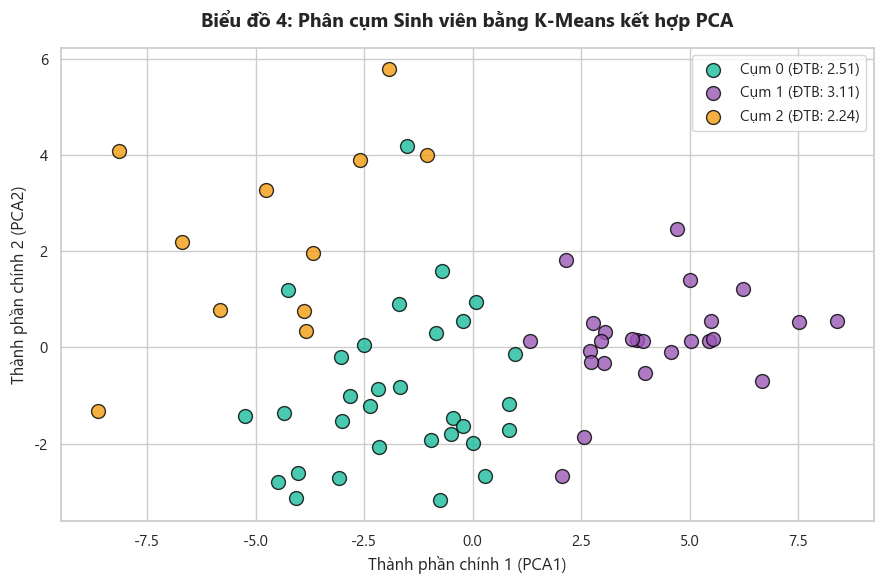

In [10]:
# Thiết lập ma trận đặc trưng X_raw bằng cách chuyển vị ma trận điểm (dòng: sinh viên, cột: môn học)
X_raw = cleaned_scores[:, valid_mask].T

# Điền khuyết dữ liệu thiếu (NaN) bằng điểm trung bình GPA của chính sinh viên đó để tránh làm sai lệch học lực
X_imputed = X_raw.copy() # Nhân bản ma trận đặc trưng gốc
for i in range(X_imputed.shape[0]):
    row = X_imputed[i] # Lấy danh sách điểm các môn của sinh viên thứ i
    row_gpa = df_students.iloc[i]['GPA'] # Lấy điểm GPA trung bình tích lũy của chính sinh viên thứ i
    X_imputed[i, np.isnan(row)] = row_gpa # Tìm các ô điểm trống (NaN) môn học và gán bằng giá trị GPA tích lũy của sinh viên đó

# Khởi tạo bộ chuẩn hóa dữ liệu Standard Scaler theo phân phối chuẩn Z-Score (Trung bình = 0, Phương sai = 1)
scaler = StandardScaler()
# Thực hiện chuẩn hóa ma trận đặc trưng điểm sau khi điền khuyết để thuật toán K-Means không bị lệch do khoảng điểm
X_scaled = scaler.fit_transform(X_imputed)

# Khởi tạo mô hình phân cụm K-Means với K=3 cụm học lực, đặt seed random_state=42 để kết quả phân cụm không đổi mỗi lần chạy
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# Thực hiện chạy thuật toán K-Means phân cụm trên dữ liệu điểm đã chuẩn hóa và gán nhãn cụm (0, 1, 2) cho từng sinh viên
labels = kmeans.fit_predict(X_scaled)
# Ghi nhãn cụm học tập đã dự đoán vào cột 'Cluster' của DataFrame sinh viên
df_students['Cluster'] = labels

# Khởi tạo bộ giảm chiều dữ liệu PCA (Phân tích thành phần chính) để giảm 52 môn học xuống còn 2 thành phần chính chính
pca = PCA(n_components=2)
# Tiến hành giảm chiều ma trận điểm đã chuẩn hóa xuống không gian 2D (PCA1, PCA2)
X_pca = pca.fit_transform(X_scaled)
# Lưu tọa độ thành phần chính thứ nhất vào cột 'PCA1'
df_students['PCA1'] = X_pca[:, 0]
# Lưu tọa độ thành phần chính thứ hai vào cột 'PCA2'
df_students['PCA2'] = X_pca[:, 1]

# In ra thống kê đặc trưng của từng cụm (số sinh viên, điểm trung bình cụm, khoảng điểm gpa của cụm)
print("Kết quả phân cụm sinh viên:")
for cluster_id in range(3):
    # Lọc ra tập hợp sinh viên thuộc cụm đang xét
    cluster_data = df_students[df_students['Cluster'] == cluster_id]
    # In thông tin thống kê tóm tắt học lực của cụm
    print(f" * Cụm {cluster_id}: {len(cluster_data)} SV | ĐTB GPA: {cluster_data['GPA'].mean():.4f} | Khoảng GPA: [{cluster_data['GPA'].min():.4f} - {cluster_data['GPA'].max():.4f}]")

# Vẽ biểu đồ phân tán (Scatter Plot) trực quan hóa các cụm sinh viên trên mặt phẳng PCA 2 chiều
plt.figure(figsize=(9, 6))
# Định nghĩa các màu sắc biểu diễn cho 3 cụm học tập
scatter_colors = ['#1abc9c', '#9b59b6', '#f39c12']
# Duyệt qua từng cụm để vẽ các điểm biểu diễn sinh viên lên hệ trục tọa độ PCA
for cluster_id in range(3):
    cluster_data = df_students[df_students['Cluster'] == cluster_id]
    # Vẽ các điểm sinh viên lên mặt phẳng với tọa độ PCA1, PCA2, gán nhãn màu sắc riêng theo cụm học tập
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], 
                color=scatter_colors[cluster_id], 
                label=f'Cụm {cluster_id} (ĐTB: {cluster_data["GPA"].mean():.2f})', 
                s=100, alpha=0.8, edgecolors='black')

# Đặt tiêu đề cho biểu đồ trực quan hóa cụm
plt.title('Biểu đồ 4: Phân cụm Sinh viên bằng K-Means kết hợp PCA', fontsize=14, fontweight='bold', pad=15)
# Đặt tên trục hoành là thành phần chính thứ nhất (PCA1)
plt.xlabel('Thành phần chính 1 (PCA1)', fontsize=12)
# Đặt tên trục tung là thành phần chính thứ hai (PCA2)
plt.ylabel('Thành phần chính 2 (PCA2)', fontsize=12)
# Hiển thị bảng chú thích ở góc tối ưu trên biểu đồ
plt.legend(fontsize=11)
# Căn chỉnh lề tự động tránh mất chữ
plt.tight_layout()
# Hiển thị biểu đồ
plt.show()


## 5. Đặc Điểm Chung Của Nhóm Sinh Viên Có Kết Quả Học Tập Cao
Ở phần này, chúng ta phân tích đặc điểm chung của nhóm sinh viên có kết quả học tập cao (GPA tích lũy $\ge 3.0$) so với các sinh viên còn lại (GPA tích lũy $< 3.0$). 
Phân tích này giúp chỉ ra môn học nào đóng vai trò phân hóa mạnh nhất quyết định vị thế sinh viên xuất sắc của lớp K58KTP.

Top 6 môn học có sự phân hóa điểm lớn nhất giữa 2 nhóm:
 - Đại số tuyến tính (BAS0108): Nhóm cao=3.79 | Nhóm còn lại=2.20 | Chênh lệch=1.60
 - Giải tích 2 (BAS0205): Nhóm cao=3.02 | Nhóm còn lại=1.65 | Chênh lệch=1.37
 - Toán 2(Giải tích 1) (BAS109): Nhóm cao=3.45 | Nhóm còn lại=2.09 | Chênh lệch=1.36
 - Hệ thống nhúng (TEE403): Nhóm cao=3.50 | Nhóm còn lại=2.20 | Chênh lệch=1.30
 - Kiến trúc máy tính (TEE415): Nhóm cao=3.41 | Nhóm còn lại=2.14 | Chênh lệch=1.27
 - Xử lý tín hiệu số (TEE314): Nhóm cao=2.99 | Nhóm còn lại=1.74 | Chênh lệch=1.26


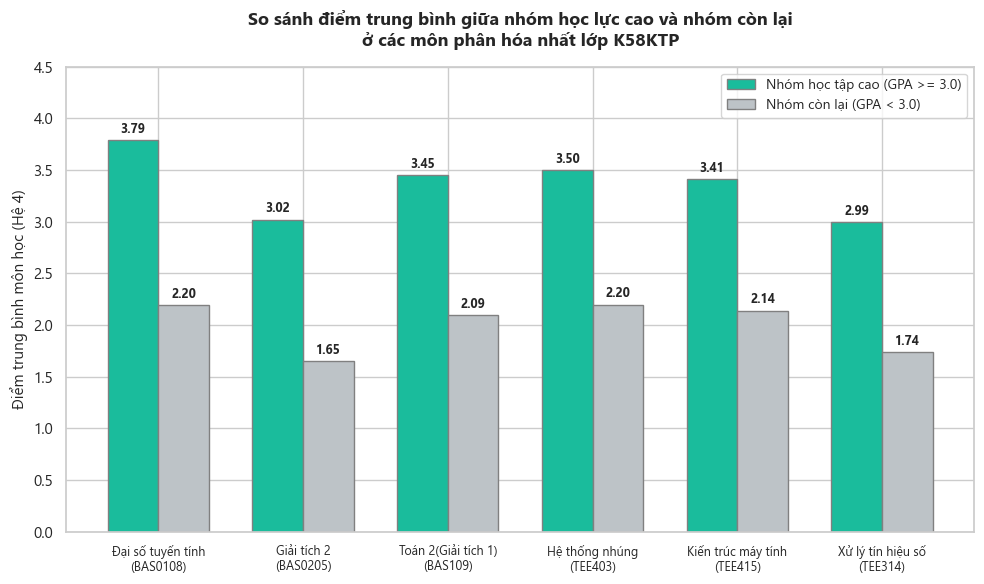

In [11]:
# Phân chia thành 2 nhóm sinh viên dựa trên điểm GPA tích lũy
# Lọc ra mask True/False cho các sinh viên có GPA >= 3.0 (nhóm học lực cao)
high_perf_mask = (df_students['GPA'] >= 3.0).values
# Trích xuất ma trận điểm của nhóm học lực cao (GPA >= 3.0)
X_high = X_raw[high_perf_mask]
# Trích xuất ma trận điểm của nhóm còn lại (GPA < 3.0)
X_low = X_raw[~high_perf_mask]

# Duyệt qua từng môn học để tính điểm trung bình của 2 nhóm và so sánh chênh lệch
diffs = []
for idx in range(len(subj_names)):
    # Tính điểm trung bình của môn thứ idx trong nhóm giỏi (bỏ qua các giá trị NaN)
    mean_high = np.nanmean(X_high[:, idx])
    # Tính điểm trung bình của môn thứ idx trong nhóm còn lại (bỏ qua các giá trị NaN)
    mean_low = np.nanmean(X_low[:, idx])
    # Nếu cả hai nhóm đều có điểm môn này, lưu lại kết quả chênh lệch
    if not np.isnan(mean_high) and not np.isnan(mean_low):
        diffs.append({
            'TenMon': subj_names[idx],
            'MaMon': subj_ids[idx],
            'MeanHigh': mean_high,
            'MeanLow': mean_low,
            'Diff': mean_high - mean_low # Tính chênh lệch điểm số
        })

# Chuyển danh sách chênh lệch sang DataFrame và sắp xếp giảm dần theo chênh lệch (Diff)
df_diffs = pd.DataFrame(diffs).sort_values(by='Diff', ascending=False)
print("Top 6 môn học có sự phân hóa điểm lớn nhất giữa 2 nhóm:")
top_6_diff = df_diffs.head(6) # Lấy 6 môn học có chênh lệch điểm lớn nhất
for idx, row in top_6_diff.iterrows():
    print(f" - {row['TenMon']} ({row['MaMon']}): Nhóm cao={row['MeanHigh']:.2f} | Nhóm còn lại={row['MeanLow']:.2f} | Chênh lệch={row['Diff']:.2f}")

# Vẽ biểu đồ cột ghép (Grouped Bar Chart) so sánh 2 nhóm sinh viên
x = np.arange(len(top_6_diff))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
# Vẽ cột điểm trung bình của nhóm học lực cao (màu xanh lá/teal)
rects1 = ax.bar(x - width/2, top_6_diff['MeanHigh'], width, label='Nhóm học tập cao (GPA >= 3.0)', color='#1abc9c', edgecolor='grey')
# Vẽ cột điểm trung bình của nhóm còn lại (màu xám)
rects2 = ax.bar(x + width/2, top_6_diff['MeanLow'], width, label='Nhóm còn lại (GPA < 3.0)', color='#bdc3c7', edgecolor='grey')

ax.set_title('So sánh điểm trung bình giữa nhóm học lực cao và nhóm còn lại\nở các môn phân hóa nhất lớp K58KTP', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Điểm trung bình môn học (Hệ 4)', fontsize=11)
ax.set_xticks(x)
# Nhãn hiển thị Tên môn học và Mã môn học
display_names = [f"{row['TenMon']}\n({row['MaMon']})" for _, row in top_6_diff.iterrows()]
ax.set_xticklabels(display_names, fontsize=9, rotation=0)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, 4.5)

# Hàm tự động ghi điểm số cụ thể lên đầu mỗi cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


## 6. Tổng Kết 


1. **Lực học tổng quan**: Lớp K58KTP học khá tốt, điểm trung bình đạt **2.69**.
2. **Thế mạnh CNTT**: Sinh viên làm quen và học rất tốt các môn lập trình ứng dụng như *Lập trình Python* (3.62), *An toàn bảo mật* (3.61), *Hệ quản trị CSDL* (3.51), *OOP* (3.33).
3. **Mặt hạn chế**: Lớp học phân hóa thành 3 nhóm rõ rệt, trong đó có **11 sinh viên (Cụm 2)** gặp nhiều khó khăn với GPA trung bình cụm chỉ đạt **2.24** và **2 sinh viên học lực Yếu (GPA < 2.0)**. Ngoài ra, điểm số của lớp ở các môn Giáo dục thể chất (1.82) và Vật lý 1 (1.93) cực kỳ thấp.


